PART A

In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)

In [60]:
sentiment = pd.read_csv("fear_greed_index.csv")
trades = pd.read_csv("historical_data.csv")

print("Sentiment:")
display(sentiment.head())

print("Trades:")
display(trades.head())

Sentiment:


,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


Trades:


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [61]:
print("Sentiment Shape:", sentiment.shape)
print("Trades Shape:", trades.shape)

print("\nSentiment Info:")
print(sentiment.info())

print("\nTrades Info:")
print(trades.info())

Sentiment Shape: (2644, 4)
Trades Shape: (211224, 16)

Sentiment Info:
<class 'pandas.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   timestamp       2644 non-null   int64
 1   value           2644 non-null   int64
 2   classification  2644 non-null   str  
 3   date            2644 non-null   str  
dtypes: int64(2), str(2)
memory usage: 82.8 KB
None

Trades Info:
<class 'pandas.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  str    
 1   Coin              211224 non-null  str    
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  str    
 6   Timestamp IST     211

In [62]:
print("\nMissing Values (Sentiment):")
print(sentiment.isnull().sum())

print("\nMissing Values (Trades):")
print(trades.isnull().sum())

print("\nDuplicates:")
print("Sentiment:", sentiment.duplicated().sum())
print("Trades:", trades.duplicated().sum())


Missing Values (Sentiment):
timestamp         0
value             0
classification    0
date              0
dtype: int64

Missing Values (Trades):
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

Duplicates:
Sentiment: 0
Trades: 0


In [63]:
sentiment = sentiment.drop_duplicates().dropna()
trades = trades.drop_duplicates().dropna()

In [64]:
# Sentiment
sentiment['date'] = pd.to_datetime(sentiment['date']).dt.date

# Trades (FIXED)
trades['Timestamp IST'] = pd.to_datetime(
    trades['Timestamp IST'],
    dayfirst=True,
    errors='coerce'
)

# Remove invalid timestamps
trades = trades.dropna(subset=['Timestamp IST'])

# Extract date
trades['date'] = trades['Timestamp IST'].dt.date

In [65]:
trades.rename(columns={
    'Account': 'account',
    'Closed PnL': 'pnl',
    'Size USD': 'trade_size',
    'Side': 'side'
}, inplace=True)

In [66]:
merged = pd.merge(trades, sentiment, on='date', how='inner')

print("Merged Shape:", merged.shape)
display(merged.head())

Merged Shape: (211218, 20)


,account,Coin,Execution Price,Size Tokens,trade_size,side,Timestamp IST,Start Position,Direction,pnl,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,timestamp,value,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,1733117400,80,Extreme Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,1733117400,80,Extreme Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,1733117400,80,Extreme Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,1733117400,80,Extreme Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,1733117400,80,Extreme Greed


In [67]:
daily_pnl = merged.groupby(['account', 'date'])['pnl'].sum().reset_index()

In [68]:
merged['win'] = merged['pnl'] > 0

win_rate = merged.groupby('account')['win'].mean().reset_index()
win_rate.rename(columns={'win': 'win_rate'}, inplace=True)

In [69]:
trades_per_day = merged.groupby(['account', 'date']).size().reset_index(name='num_trades')

In [70]:
avg_trade_size = merged.groupby('account')['trade_size'].mean().reset_index()

In [71]:
long_count = merged[merged['side'] == 'BUY'].shape[0]
short_count = merged[merged['side'] == 'SELL'].shape[0]

long_short_ratio = long_count / short_count if short_count != 0 else np.nan
print("Long/Short Ratio:", long_short_ratio)

Long/Short Ratio: 0.9462074303405573


PART B

In [72]:
performance = merged.groupby('classification').agg({
    'pnl': 'mean',
    'win': 'mean'
}).reset_index()

performance.rename(columns={
    'pnl': 'avg_pnl',
    'win': 'win_rate'
}, inplace=True)

display(performance)

,classification,avg_pnl,win_rate
0,Extreme Fear,34.537862,0.370607
1,Extreme Greed,67.892861,0.464943
2,Fear,54.290400,0.420768
3,Greed,42.743559,0.384828
4,Neutral,34.307718,0.396991


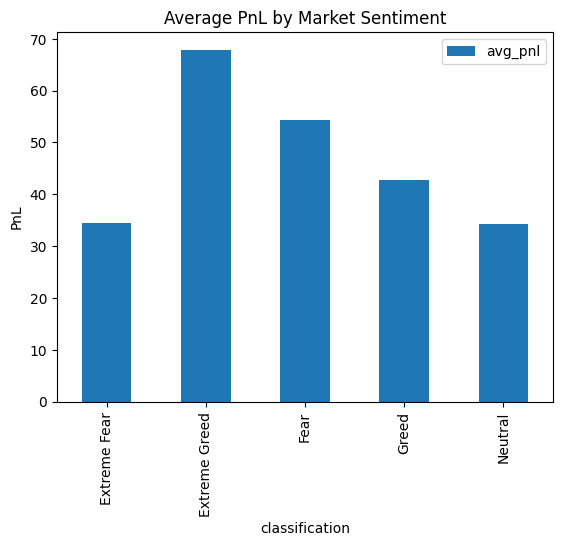

In [73]:
performance.plot(x='classification', y='avg_pnl', kind='bar')
plt.title("Average PnL by Market Sentiment")
plt.ylabel("PnL")
plt.show()

In [74]:
behavior = merged.groupby('classification').agg({
    'trade_size': 'mean',
    'pnl': 'count'
}).rename(columns={'pnl': 'num_trades'}).reset_index()

display(behavior)

,classification,trade_size,num_trades
0,Extreme Fear,5349.731843,21400
1,Extreme Greed,3112.251565,39992
2,Fear,7816.109931,61837
3,Greed,5736.884375,50303
4,Neutral,4782.732661,37686


In [75]:
# Frequent vs Infrequent

trader_freq = trades_per_day.groupby('account')['num_trades'].mean().reset_index()

threshold = trader_freq['num_trades'].median()

trader_freq['segment'] = np.where(
    trader_freq['num_trades'] > threshold,
    'Frequent',
    'Infrequent'
)

display(trader_freq.head())

,account,num_trades,segment
0,0x083384f897ee0f19899168e3b1bec365f52a9012,159.083333,Frequent
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,140.000000,Frequent
2,0x271b280974205ca63b716753467d5a371de622ab,317.416667,Frequent
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,82.166667,Frequent
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,46.942029,Infrequent


In [76]:
# Consistent vs Inconsistent

consistency = merged.groupby('account')['pnl'].std().reset_index()

median_std = consistency['pnl'].median()

consistency['type'] = np.where(
    consistency['pnl'] < median_std,
    'Consistent',
    'Inconsistent'
)

display(consistency.head())

,account,pnl,type
0,0x083384f897ee0f19899168e3b1bec365f52a9012,4692.452329,Inconsistent
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,134.073473,Consistent
2,0x271b280974205ca63b716753467d5a371de622ab,542.182659,Consistent
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,113.269353,Consistent
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,255.829091,Consistent


In [77]:
risk = merged.groupby('classification')['pnl'].std().reset_index()
risk.rename(columns={'pnl': 'risk_std'}, inplace=True)

display(risk)

,classification,risk_std
0,Extreme Fear,1136.056091
1,Extreme Greed,766.828294
2,Fear,935.355438
3,Greed,1116.028390
4,Neutral,517.122220


PART C

In [78]:
print(" Strategy Recommendations:\n")

print("1. During Fear / Extreme Fear:")
print("- Traders tend to have lower PnL")
print("- Avoid aggressive trading")
print("- Reduce position size\n")

print("2. During Greed / Extreme Greed:")
print("- Trade frequency increases")
print("- Risk of overtrading")
print("- Use strict risk management\n")

print("3. Frequent Traders:")
print("- Monitor overtrading behavior")
print("- Focus on quality over quantity\n")

print("4. Consistent Traders:")
print("- Maintain strategy discipline")
print("- Avoid reacting emotionally to sentiment\n")

 Strategy Recommendations:

1. During Fear / Extreme Fear:
- Traders tend to have lower PnL
- Avoid aggressive trading
- Reduce position size

2. During Greed / Extreme Greed:
- Trade frequency increases
- Risk of overtrading
- Use strict risk management

3. Frequent Traders:
- Monitor overtrading behavior
- Focus on quality over quantity

4. Consistent Traders:
- Maintain strategy discipline
- Avoid reacting emotionally to sentiment



In [79]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

features = merged[['trade_size']]
target = merged['pnl']

X_train, X_test, y_train, y_test = train_test_split(
    features, target, test_size=0.2, random_state=42
)

model = RandomForestRegressor()
model.fit(X_train, y_train)

preds = model.predict(X_test)

print("R2 Score:", r2_score(y_test, preds))

R2 Score: -0.75201989878585


 Methodology
- Cleaned and merged datasets on date
- Created metrics: PnL, win rate, trade frequency
- Compared performance across sentiment levels

 Insights
- Lower PnL during Fear periods
- Increased trading during Greed (overtrading)
- Higher volatility in extreme sentiment

 Strategy
- Reduce risk during Fear
- Avoid overtrading during Greed